Seed установлен: 42
Используемое устройство: cpu
Загрузка FashionMNIST...
 FashionMNIST успешно загружен!

Размер train: 48000
Размер val: 12000
Размер test: 10000

Форма батча изображений: torch.Size([64, 1, 28, 28])
Форма батча меток: torch.Size([64])
Диапазон значений: [-1.000, 1.000]
Уникальные классы: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


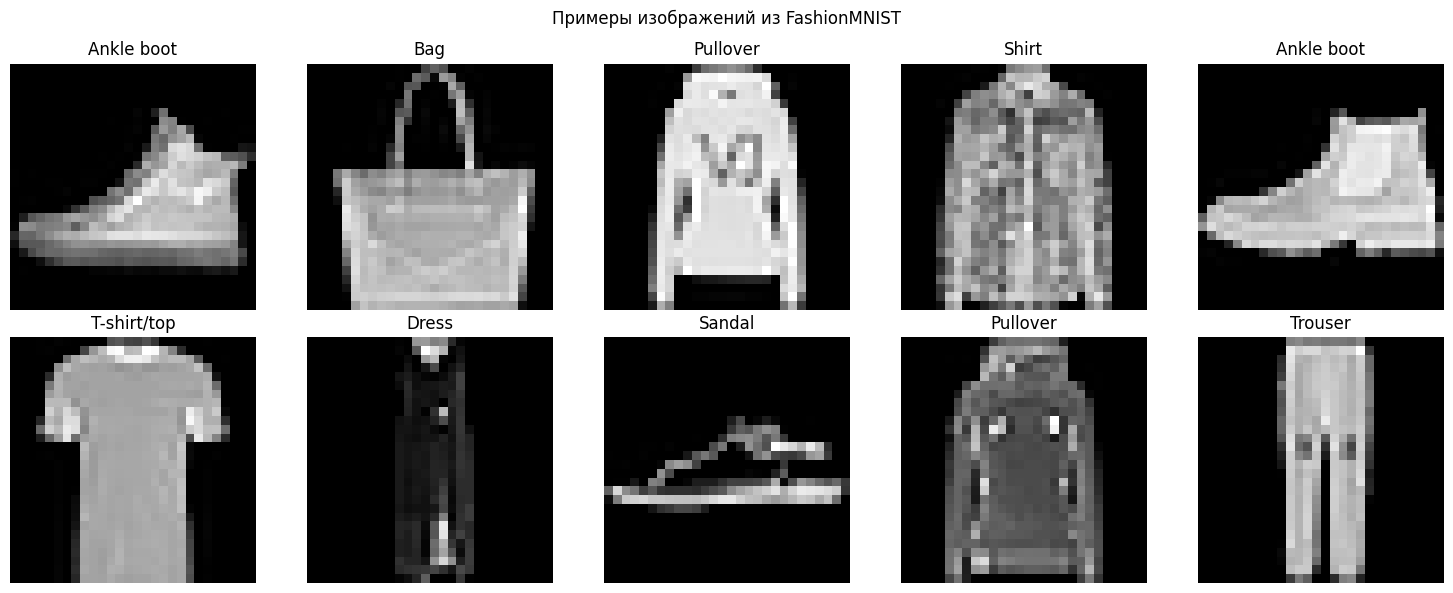

DataFrame для результатов создан

ЭКСПЕРИМЕНТ E1: Базовая модель (без регуляризации)
Архитектура: 512-256 ReLU noBN nodrop
Параметров: 535,818

Начало обучения на 15 эпох...
------------------------------------------------------------
Эпоха [1/15] Loss: 0.5010 | Acc: 81.59% | Val Loss: 0.4140 | Val Acc: 84.53%
Эпоха [2/15] Loss: 0.3756 | Acc: 86.15% | Val Loss: 0.3768 | Val Acc: 86.31%
Эпоха [3/15] Loss: 0.3352 | Acc: 87.48% | Val Loss: 0.3590 | Val Acc: 86.96%
Эпоха [4/15] Loss: 0.3099 | Acc: 88.40% | Val Loss: 0.3466 | Val Acc: 87.84%
Эпоха [5/15] Loss: 0.2869 | Acc: 89.12% | Val Loss: 0.3304 | Val Acc: 87.22%
Эпоха [6/15] Loss: 0.2715 | Acc: 89.69% | Val Loss: 0.3265 | Val Acc: 88.24%
Эпоха [7/15] Loss: 0.2533 | Acc: 90.46% | Val Loss: 0.3240 | Val Acc: 88.83%
Эпоха [8/15] Loss: 0.2394 | Acc: 90.96% | Val Loss: 0.3281 | Val Acc: 88.35%
Эпоха [9/15] Loss: 0.2270 | Acc: 91.41% | Val Loss: 0.3289 | Val Acc: 88.82%
Эпоха [10/15] Loss: 0.2140 | Acc: 91.91% | Val Loss: 0.3237 | Val Acc: 8

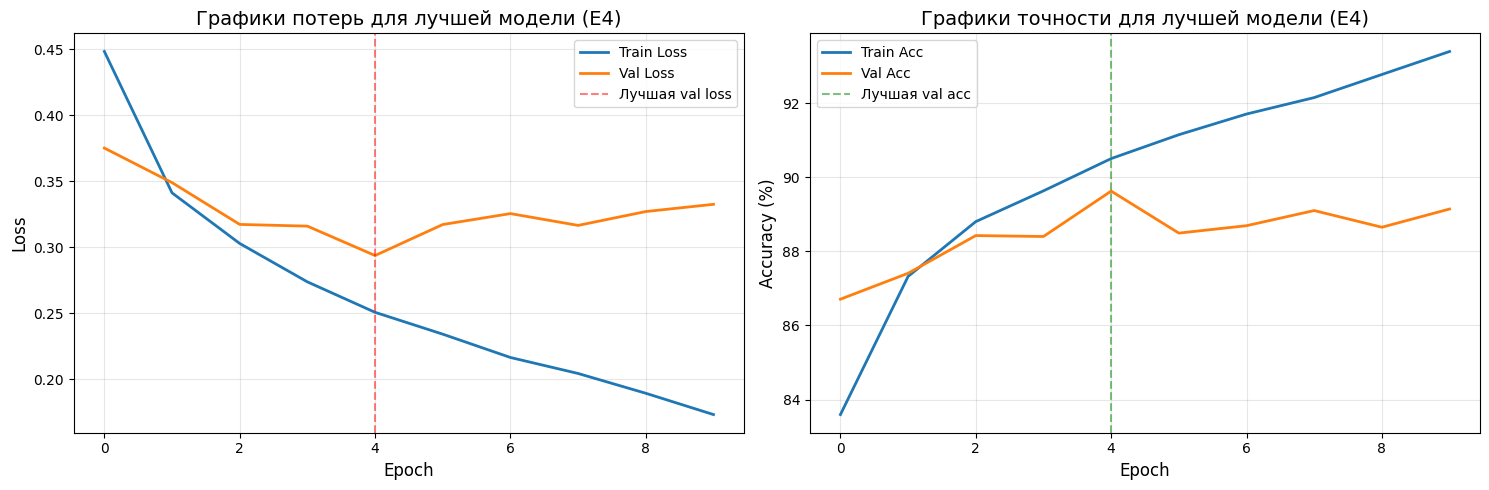

 График сохранен: artifacts/figures/curves_best.png

ЭКСПЕРИМЕНТ O1: Слишком большой LR (0.1)
Архитектура: 512-256 ReLU BN nodrop
LR: 0.1 (слишком большой)

Начало обучения на 8 эпох...
------------------------------------------------------------
Эпоха [1/8] Loss: 0.6000 | Acc: 79.10% | Val Loss: 0.4580 | Val Acc: 83.92%
Эпоха [2/8] Loss: 0.4536 | Acc: 83.85% | Val Loss: 0.4137 | Val Acc: 85.11%
Эпоха [3/8] Loss: 0.4254 | Acc: 84.77% | Val Loss: 0.4199 | Val Acc: 85.43%
Эпоха [4/8] Loss: 0.3963 | Acc: 85.75% | Val Loss: 0.3790 | Val Acc: 86.72%
Эпоха [5/8] Loss: 0.3721 | Acc: 86.50% | Val Loss: 0.3999 | Val Acc: 85.90%
Эпоха [6/8] Loss: 0.3659 | Acc: 86.79% | Val Loss: 0.3550 | Val Acc: 87.28%
Эпоха [7/8] Loss: 0.3454 | Acc: 87.50% | Val Loss: 0.3710 | Val Acc: 86.75%
Эпоха [8/8] Loss: 0.3377 | Acc: 87.99% | Val Loss: 0.3613 | Val Acc: 88.07%
------------------------------------------------------------

 O1 завершен. Лучшая val accuracy: 88.07%

ЭКСПЕРИМЕНТ O2: Слишком маленький LR (1e

/var/folders/jq/f4hl0z3n74j8jcks3qshqwxw0000gn/T/ipykernel_1445/1946945331.py:667: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  runs_df.loc[len(runs_df)] = [


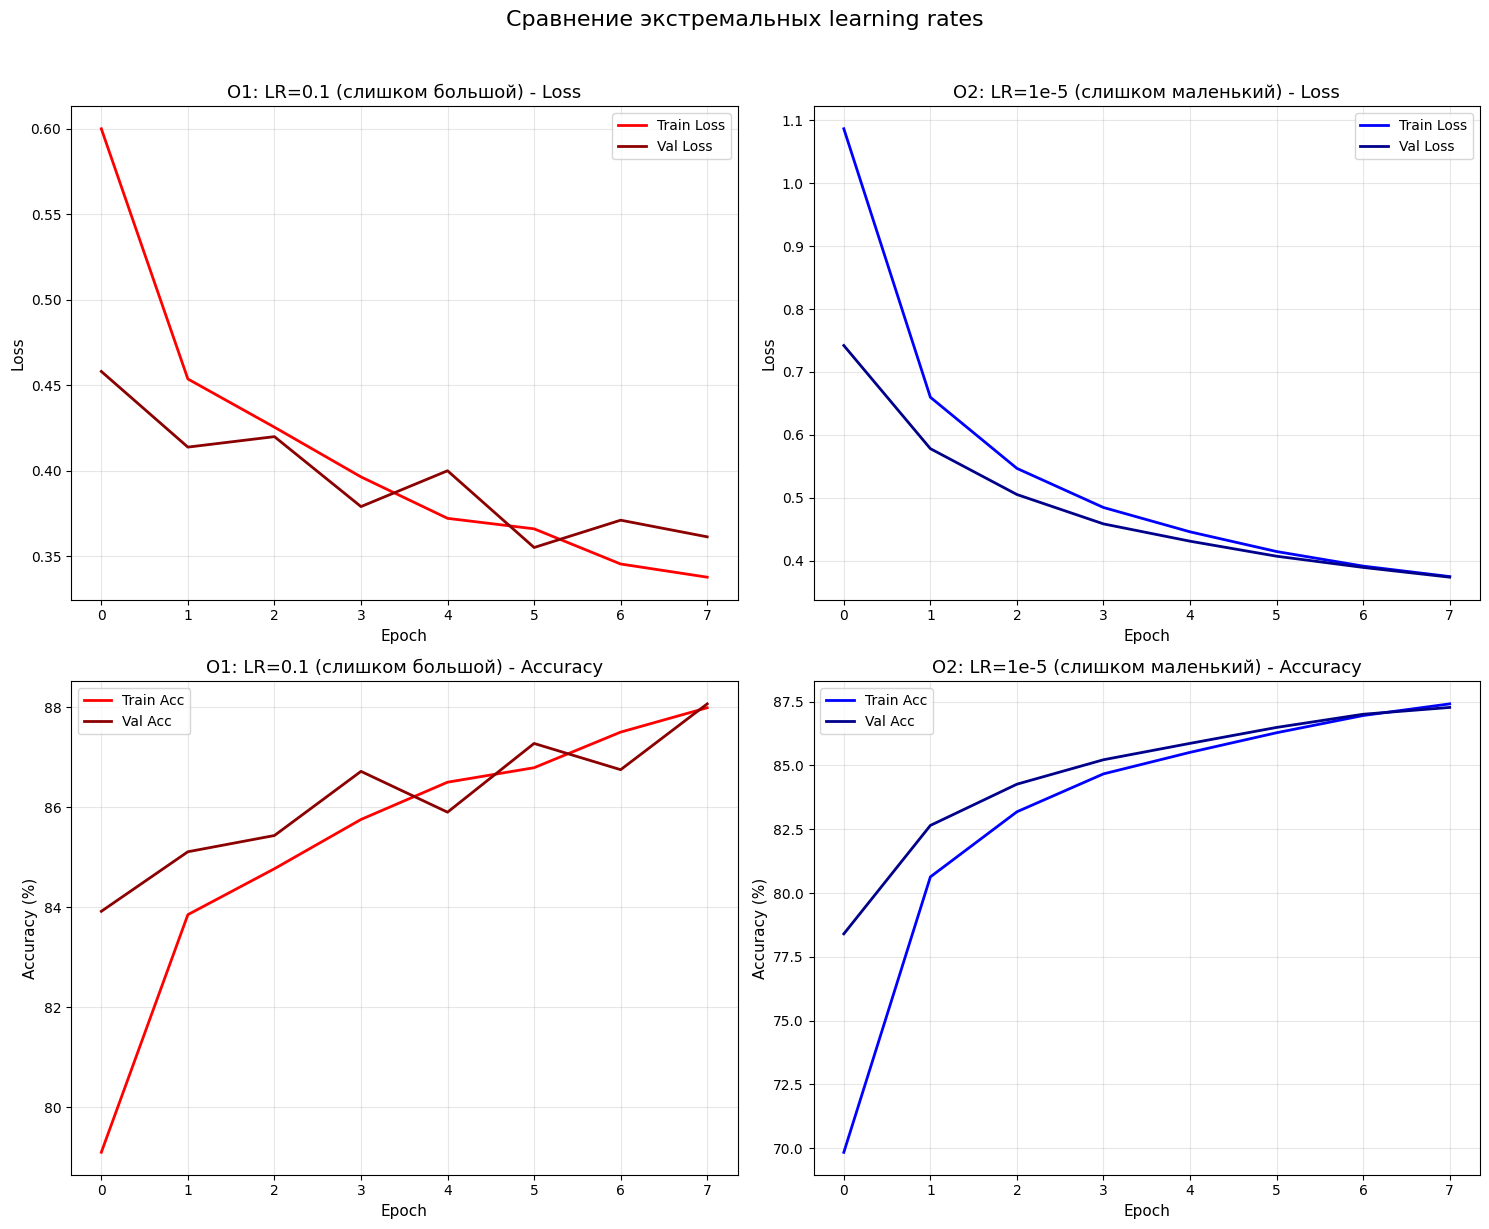

 График сохранен: artifacts/figures/curves_lr_extremes.png

ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ ЛУЧШЕЙ МОДЕЛИ (E4)
Test Loss: 0.3532
Test Accuracy: 88.64%
 Конфиг обновлен с test accuracy

РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТОВ
experiment_id      dataset  seed                model_summary optimizer      lr  momentum  weight_decay  epochs_trained  best_val_accuracy  best_val_loss
           E1 FashionMNIST    42     512-256 ReLU noBN nodrop      Adam 0.00100       NaN        0.0000              15          89.300000       0.323674
           E2 FashionMNIST    42 512-256 ReLU noBN dropout0.3      Adam 0.00100       NaN        0.0000              15          89.008333       0.318912
           E3 FashionMNIST    42       512-256 ReLU BN nodrop      Adam 0.00100       NaN        0.0000              15          89.775000       0.292266
           E4 FashionMNIST    42       512-256 ReLU BN nodrop      Adam 0.00100       NaN        0.0000              10          89.625000       0.293680
           O1 FashionMNIST   

In [7]:

# # HW08-09: Регуляризация и оптимизация MLP на FashionMNIST
# ## Вариант А: FashionMNIST


# ### 1. Импорты, seed и устройство

# %%
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os
import random
from pathlib import Path


Path("artifacts/figures").mkdir(parents=True, exist_ok=True)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Seed установлен: {seed}")

set_seed(42)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")


# %% [markdown]
# ### 2. Загрузка и подготовка данных (FashionMNIST)

# %%
# Трансформации для данных
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Нормализация для grayscale
])

# Загружаем FashionMNIST (работает стабильно)
print("Загрузка FashionMNIST...")
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)
print(" FashionMNIST успешно загружен!")

# Разбиваем train на train/val (80/20)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(
    train_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Создаем DataLoader'ы
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Проверка данных
print(f"\nРазмер train: {len(train_dataset)}")
print(f"Размер val: {len(val_dataset)}")
print(f"Размер test: {len(test_dataset)}")

# Проверяем батч
images, labels = next(iter(train_loader))
print(f"\nФорма батча изображений: {images.shape}")
print(f"Форма батча меток: {labels.shape}")
print(f"Диапазон значений: [{images.min():.3f}, {images.max():.3f}]")
print(f"Уникальные классы: {labels.unique().tolist()}")

# Названия классов FashionMNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Визуализируем примеры
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{class_names[labels[i]]}')
    ax.axis('off')
plt.suptitle('Примеры изображений из FashionMNIST')
plt.tight_layout()
plt.savefig('artifacts/figures/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

# ### 3. Создание MLP модели

# %%
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_sizes=[512, 256], 
                 num_classes=10, dropout=0.0, use_batchnorm=False):
        super(MLP, self).__init__()
        
        layers = []
        prev_size = input_size
        
        # Добавляем скрытые слои
        for i, hidden_size in enumerate(hidden_sizes):
            # Linear слой
            layers.append(nn.Linear(prev_size, hidden_size))
            
            # BatchNorm (если включена)
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))
            
            # Активация
            layers.append(nn.ReLU())
            
            # Dropout (если > 0)
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            
            prev_size = hidden_size
        
        # Выходной слой
        layers.append(nn.Linear(prev_size, num_classes))
        
        # Объединяем все слои
        self.layers = nn.Sequential(*layers)
        self.flatten = nn.Flatten()
        
        # Сохраняем параметры для summary
        self.config = {
            'input_size': input_size,
            'hidden_sizes': hidden_sizes,
            'num_classes': num_classes,
            'dropout': dropout,
            'use_batchnorm': use_batchnorm
        }
    
    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)
    
    def get_summary(self):
        """Возвращает краткое описание модели"""
        bn_str = "BN" if self.config['use_batchnorm'] else "noBN"
        dropout_str = f"dropout{self.config['dropout']}" if self.config['dropout'] > 0 else "nodrop"
        hidden_str = '-'.join(str(h) for h in self.config['hidden_sizes'])
        return f"{hidden_str} ReLU {bn_str} {dropout_str}"

# %% [markdown]
# ### 4. Функции для обучения и оценки

# %%
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """Обучение на одной эпохе"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Статистика
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def evaluate(model, data_loader, criterion, device):
    """Оценка модели на данных"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(data_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def train_model(model, train_loader, val_loader, criterion, optimizer, 
                num_epochs, device, early_stopping_patience=None):
    """Полный цикл обучения с логированием"""
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    best_val_acc = 0
    best_model_state = None
    patience_counter = 0
    best_epoch = 0
    
    print(f"\nНачало обучения на {num_epochs} эпох...")
    print("-" * 60)
    
    for epoch in range(num_epochs):
        # Обучение
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        
        # Валидация
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        # Сохраняем историю
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Вывод прогресса
        print(f'Эпоха [{epoch+1}/{num_epochs}] '
              f'Loss: {train_loss:.4f} | Acc: {train_acc:.2f}% | '
              f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')
        
        # Early stopping
        if early_stopping_patience is not None:
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_state = model.state_dict().copy()
                patience_counter = 0
                best_epoch = epoch
            else:
                patience_counter += 1
                
            if patience_counter >= early_stopping_patience:
                print(f"\nРанняя остановка на эпохе {epoch+1}")
                print(f"Лучшая модель на эпохе {best_epoch+1} с Val Acc: {best_val_acc:.2f}%")
                break
    
    # Загружаем лучшую модель если использовали early stopping
    if early_stopping_patience is not None and best_model_state is not None:
        model.load_state_dict(best_model_state)
        print("Загружена лучшая модель")
    
    print("-" * 60)
    return history

# %% [markdown]
# ### 5. Инициализация DataFrame для результатов

# %%
# Создаем DataFrame для сохранения результатов
runs_df = pd.DataFrame(columns=[
    'experiment_id', 'dataset', 'seed', 'model_summary', 
    'optimizer', 'lr', 'momentum', 'weight_decay',
    'epochs_trained', 'best_val_accuracy', 'best_val_loss'
])

# Общие параметры
criterion = nn.CrossEntropyLoss()
input_size = 28 * 28
num_classes = 10
num_epochs = 15  # для E1-E3
print("DataFrame для результатов создан")

# %% [markdown]
# ## Часть A: Эксперименты с регуляризацией (E1-E4)

# %% [markdown]
# ### E1: Базовая модель (без регуляризации)

# %%
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ E1: Базовая модель (без регуляризации)")
print("="*60)

# Создаем модель
model_e1 = MLP(
    input_size=input_size, 
    hidden_sizes=[512, 256], 
    num_classes=num_classes,
    dropout=0.0,
    use_batchnorm=False
).to(device)

print(f"Архитектура: {model_e1.get_summary()}")
print(f"Параметров: {sum(p.numel() for p in model_e1.parameters()):,}")

# Оптимизатор
optimizer_e1 = optim.Adam(model_e1.parameters(), lr=0.001)

# Обучение
history_e1 = train_model(
    model_e1, train_loader, val_loader, 
    criterion, optimizer_e1, num_epochs, device
)

# Сохраняем результаты
runs_df.loc[len(runs_df)] = [
    'E1', 'FashionMNIST', 42, model_e1.get_summary(),
    'Adam', 0.001, None, 0,
    num_epochs, max(history_e1['val_acc']), min(history_e1['val_loss'])
]

print(f"\nE1 завершен. Лучшая val accuracy: {max(history_e1['val_acc']):.2f}%")

# %% [markdown]
# ### E2: Модель с Dropout

# %%
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ E2: Модель с Dropout (p=0.3)")
print("="*60)

# Создаем модель с Dropout
model_e2 = MLP(
    input_size=input_size, 
    hidden_sizes=[512, 256], 
    num_classes=num_classes,
    dropout=0.3,
    use_batchnorm=False
).to(device)

print(f"Архитектура: {model_e2.get_summary()}")
print(f"Параметров: {sum(p.numel() for p in model_e2.parameters()):,}")

# Оптимизатор
optimizer_e2 = optim.Adam(model_e2.parameters(), lr=0.001)

# Обучение
history_e2 = train_model(
    model_e2, train_loader, val_loader, 
    criterion, optimizer_e2, num_epochs, device
)

# Сохраняем результаты
runs_df.loc[len(runs_df)] = [
    'E2', 'FashionMNIST', 42, model_e2.get_summary(),
    'Adam', 0.001, None, 0,
    num_epochs, max(history_e2['val_acc']), min(history_e2['val_loss'])
]

print(f"\n E2 завершен. Лучшая val accuracy: {max(history_e2['val_acc']):.2f}%")

# %% [markdown]
# ### E3: Модель с BatchNorm

# %%
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ E3: Модель с BatchNorm")
print("="*60)

# Создаем модель с BatchNorm
model_e3 = MLP(
    input_size=input_size, 
    hidden_sizes=[512, 256], 
    num_classes=num_classes,
    dropout=0.0,
    use_batchnorm=True
).to(device)

print(f"Архитектура: {model_e3.get_summary()}")
print(f"Параметров: {sum(p.numel() for p in model_e3.parameters()):,}")

# Оптимизатор
optimizer_e3 = optim.Adam(model_e3.parameters(), lr=0.001)

# Обучение
history_e3 = train_model(
    model_e3, train_loader, val_loader, 
    criterion, optimizer_e3, num_epochs, device
)

# Сохраняем результаты
runs_df.loc[len(runs_df)] = [
    'E3', 'FashionMNIST', 42, model_e3.get_summary(),
    'Adam', 0.001, None, 0,
    num_epochs, max(history_e3['val_acc']), min(history_e3['val_loss'])
]

print(f"\n E3 завершен. Лучшая val accuracy: {max(history_e3['val_acc']):.2f}%")

# %% [markdown]
# ### Выбор лучшей модели из E2/E3

# %%
# Сравниваем результаты E2 и E3
best_val_e2 = max(history_e2['val_acc'])
best_val_e3 = max(history_e3['val_acc'])

print("\n" + "="*60)
print("ВЫБОР ЛУЧШЕЙ МОДЕЛИ ДЛЯ E4")
print("="*60)
print(f"E2 (Dropout) лучшая val accuracy: {best_val_e2:.2f}%")
print(f"E3 (BatchNorm) лучшая val accuracy: {best_val_e3:.2f}%")

if best_val_e2 > best_val_e3:
    print("\n Выбрана конфигурация E2 (с Dropout)")
    best_config_for_e4 = {
        'dropout': 0.3,
        'use_batchnorm': False,
        'source': 'E2'
    }
else:
    print("\n Выбрана конфигурация E3 (с BatchNorm)")
    best_config_for_e4 = {
        'dropout': 0.0,
        'use_batchnorm': True,
        'source': 'E3'
    }

# %% [markdown]
# ### E4: Лучшая модель с Early Stopping

# %%
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ E4: Лучшая модель с Early Stopping")
print("="*60)

# Создаем лучшую модель
model_e4 = MLP(
    input_size=input_size, 
    hidden_sizes=[512, 256], 
    num_classes=num_classes,
    dropout=best_config_for_e4['dropout'],
    use_batchnorm=best_config_for_e4['use_batchnorm']
).to(device)

print(f"Архитектура: {model_e4.get_summary()}")
print(f"Параметров: {sum(p.numel() for p in model_e4.parameters()):,}")
print(f"Early stopping patience: 5")

# Оптимизатор
optimizer_e4 = optim.Adam(model_e4.parameters(), lr=0.001)

# Обучение с early stopping
history_e4 = train_model(
    model_e4, train_loader, val_loader, 
    criterion, optimizer_e4, 30, device,  # больше эпох для early stopping
    early_stopping_patience=5
)

epochs_trained = len(history_e4['train_loss'])

# Сохраняем результаты
runs_df.loc[len(runs_df)] = [
    'E4', 'FashionMNIST', 42, model_e4.get_summary(),
    'Adam', 0.001, None, 0,
    epochs_trained, max(history_e4['val_acc']), min(history_e4['val_loss'])
]

print(f"\n E4 завершен. Лучшая val accuracy: {max(history_e4['val_acc']):.2f}%")
print(f"Обучено эпох: {epochs_trained}")

# %% [markdown]
# ### Сохранение лучшей модели и конфига

# %%
# Сохраняем state_dict лучшей модели
torch.save(model_e4.state_dict(), 'artifacts/best_model.pt')
print(" Модель сохранена: artifacts/best_model.pt")

# Создаем и сохраняем конфиг лучшей модели
best_config = {
    'model': 'MLP',
    'input_size': input_size,
    'hidden_sizes': [512, 256],
    'num_classes': num_classes,
    'dropout': best_config_for_e4['dropout'],
    'use_batchnorm': best_config_for_e4['use_batchnorm'],
    'activation': 'ReLU',
    'optimizer': 'Adam',
    'lr': 0.001,
    'seed': 42,
    'dataset': 'FashionMNIST',
    'epochs_trained': epochs_trained,
    'best_val_accuracy': max(history_e4['val_acc']),
    'best_val_loss': min(history_e4['val_loss']),
    'early_stopping_patience': 5
}

with open('artifacts/best_config.json', 'w') as f:
    json.dump(best_config, f, indent=4)
print(" Конфиг сохранен: artifacts/best_config.json")

# %% [markdown]
# ### График для лучшей модели (E4)

# %%
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# График loss
ax1.plot(history_e4['train_loss'], label='Train Loss', linewidth=2)
ax1.plot(history_e4['val_loss'], label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Графики потерь для лучшей модели (E4)', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.axvline(x=np.argmin(history_e4['val_loss']), color='red', linestyle='--', alpha=0.5, label='Лучшая val loss')
ax1.legend()

# График accuracy
ax2.plot(history_e4['train_acc'], label='Train Acc', linewidth=2)
ax2.plot(history_e4['val_acc'], label='Val Acc', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Графики точности для лучшей модели (E4)', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.axvline(x=np.argmax(history_e4['val_acc']), color='green', linestyle='--', alpha=0.5, label='Лучшая val acc')
ax2.legend()

plt.tight_layout()
plt.savefig('artifacts/figures/curves_best.png', dpi=150, bbox_inches='tight')
plt.show()
print(" График сохранен: artifacts/figures/curves_best.png")

# %% [markdown]
# ## Часть B: Эксперименты с оптимизацией (O1-O3)

# %% [markdown]
# ### O1: Слишком большой learning rate (0.1)

# %%
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ O1: Слишком большой LR (0.1)")
print("="*60)

# Используем ту же архитектуру что и в E4
model_o1 = MLP(
    input_size=input_size, 
    hidden_sizes=[512, 256], 
    num_classes=num_classes,
    dropout=best_config_for_e4['dropout'],
    use_batchnorm=best_config_for_e4['use_batchnorm']
).to(device)

print(f"Архитектура: {model_o1.get_summary()}")
print(f"LR: 0.1 (слишком большой)")

# Оптимизатор с большим LR
optimizer_o1 = optim.Adam(model_o1.parameters(), lr=0.1)

# Обучение (меньше эпох)
history_o1 = train_model(
    model_o1, train_loader, val_loader, 
    criterion, optimizer_o1, 8, device
)

# Сохраняем результаты
runs_df.loc[len(runs_df)] = [
    'O1', 'FashionMNIST', 42, model_o1.get_summary(),
    'Adam', 0.1, None, 0,
    8, max(history_o1['val_acc']), min(history_o1['val_loss'])
]

print(f"\n O1 завершен. Лучшая val accuracy: {max(history_o1['val_acc']):.2f}%")

# %% [markdown]
# ### O2: Слишком маленький learning rate (1e-5)

# %%
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ O2: Слишком маленький LR (1e-5)")
print("="*60)

# Используем ту же архитектуру
model_o2 = MLP(
    input_size=input_size, 
    hidden_sizes=[512, 256], 
    num_classes=num_classes,
    dropout=best_config_for_e4['dropout'],
    use_batchnorm=best_config_for_e4['use_batchnorm']
).to(device)

print(f"Архитектура: {model_o2.get_summary()}")
print(f"LR: 1e-5 (слишком маленький)")

# Оптимизатор с маленьким LR
optimizer_o2 = optim.Adam(model_o2.parameters(), lr=1e-5)

# Обучение
history_o2 = train_model(
    model_o2, train_loader, val_loader, 
    criterion, optimizer_o2, 8, device
)

# Сохраняем результаты
runs_df.loc[len(runs_df)] = [
    'O2', 'FashionMNIST', 42, model_o2.get_summary(),
    'Adam', 1e-5, None, 0,
    8, max(history_o2['val_acc']), min(history_o2['val_loss'])
]

print(f"\n O2 завершен. Лучшая val accuracy: {max(history_o2['val_acc']):.2f}%")

# %% [markdown]
# ### O3: SGD + momentum + weight decay

# %%
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ O3: SGD + momentum (0.9) + weight decay (1e-4)")
print("="*60)

# Используем ту же архитектуру
model_o3 = MLP(
    input_size=input_size, 
    hidden_sizes=[512, 256], 
    num_classes=num_classes,
    dropout=best_config_for_e4['dropout'],
    use_batchnorm=best_config_for_e4['use_batchnorm']
).to(device)

print(f"Архитектура: {model_o3.get_summary()}")
print(f"Оптимизатор: SGD, lr=0.01, momentum=0.9, weight_decay=1e-4")

# Оптимизатор SGD
optimizer_o3 = optim.SGD(
    model_o3.parameters(), 
    lr=0.01, 
    momentum=0.9,
    weight_decay=1e-4
)

# Обучение
history_o3 = train_model(
    model_o3, train_loader, val_loader, 
    criterion, optimizer_o3, 12, device
)

# Сохраняем результаты
runs_df.loc[len(runs_df)] = [
    'O3', 'FashionMNIST', 42, model_o3.get_summary(),
    'SGD', 0.01, 0.9, 1e-4,
    12, max(history_o3['val_acc']), min(history_o3['val_loss'])
]

print(f"\n O3 завершен. Лучшая val accuracy: {max(history_o3['val_acc']):.2f}%")

# %% [markdown]
# ### График для O1 и O2 (экстремальные LR)

# %%
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# O1 графики
axes[0, 0].plot(history_o1['train_loss'], label='Train Loss', color='red', linewidth=2)
axes[0, 0].plot(history_o1['val_loss'], label='Val Loss', color='darkred', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('Loss', fontsize=11)
axes[0, 0].set_title('O1: LR=0.1 (слишком большой) - Loss', fontsize=13)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[1, 0].plot(history_o1['train_acc'], label='Train Acc', color='red', linewidth=2)
axes[1, 0].plot(history_o1['val_acc'], label='Val Acc', color='darkred', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=11)
axes[1, 0].set_ylabel('Accuracy (%)', fontsize=11)
axes[1, 0].set_title('O1: LR=0.1 (слишком большой) - Accuracy', fontsize=13)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# O2 графики
axes[0, 1].plot(history_o2['train_loss'], label='Train Loss', color='blue', linewidth=2)
axes[0, 1].plot(history_o2['val_loss'], label='Val Loss', color='darkblue', linewidth=2)
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('Loss', fontsize=11)
axes[0, 1].set_title('O2: LR=1e-5 (слишком маленький) - Loss', fontsize=13)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 1].plot(history_o2['train_acc'], label='Train Acc', color='blue', linewidth=2)
axes[1, 1].plot(history_o2['val_acc'], label='Val Acc', color='darkblue', linewidth=2)
axes[1, 1].set_xlabel('Epoch', fontsize=11)
axes[1, 1].set_ylabel('Accuracy (%)', fontsize=11)
axes[1, 1].set_title('O2: LR=1e-5 (слишком маленький) - Accuracy', fontsize=13)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Сравнение экстремальных learning rates', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('artifacts/figures/curves_lr_extremes.png', dpi=150, bbox_inches='tight')
plt.show()
print(" График сохранен: artifacts/figures/curves_lr_extremes.png")

# %% [markdown]
# ### Финальное тестирование лучшей модели (E4) на test set

# %%
print("\n" + "="*60)
print("ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ ЛУЧШЕЙ МОДЕЛИ (E4)")
print("="*60)

# Оцениваем на test set
test_loss, test_acc = evaluate(model_e4, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

# Добавляем информацию в best_config
best_config['test_accuracy'] = test_acc
best_config['test_loss'] = test_loss

# Обновляем конфиг
with open('artifacts/best_config.json', 'w') as f:
    json.dump(best_config, f, indent=4)
print(" Конфиг обновлен с test accuracy")

# %% [markdown]
# ### Сохранение таблицы результатов

# %%
# Сохраняем DataFrame в CSV
runs_df.to_csv('artifacts/runs.csv', index=False)
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТОВ")
print("="*60)
print(runs_df.to_string(index=False))
print(f"\n Таблица результатов сохранена: artifacts/runs.csv")

# %% [markdown]
# ### Сравнительный анализ результатов по двум частям ДЗ

# %%
print("\n" + "="*70)
print("СРАВНИТЕЛЬНЫЙ АНАЛИЗ ПО ЧАСТЯМ ДЗ (S08 и S09)")
print("="*70)

# ============================================
# ЧАСТЬ A (S08): Регуляризация
# ============================================
print("\n ЧАСТЬ A (S08): РЕГУЛЯРИЗАЦИЯ")
print("-" * 50)

e1_acc = max(history_e1['val_acc'])
e2_acc = max(history_e2['val_acc'])
e3_acc = max(history_e3['val_acc'])
e4_acc = max(history_e4['val_acc'])

print(f"E1 (Base - без регуляризации):        {e1_acc:.2f}%")
print(f"E2 (с Dropout p=0.3):                  {e2_acc:.2f}% (изменение: {e2_acc - e1_acc:+.2f}%)")
print(f"E3 (с BatchNorm):                       {e3_acc:.2f}% (изменение: {e3_acc - e1_acc:+.2f}%)")
print(f"E4 (Early Stopping - лучшая модель):    {e4_acc:.2f}%")

# Выводы по части A
print("\n ВЫВОДЫ ПО ЧАСТИ A (S08):")
print("-" * 50)

# Сравнение Dropout
if e2_acc > e1_acc:
    print(" Dropout улучшил обобщение модели (val accuracy выросла)")
elif e2_acc < e1_acc:
    print(" Dropout не помог, возможно p=0.3 слишком большой")
else:
    print(" Dropout не повлиял на качество")

# Сравнение BatchNorm
if e3_acc > e1_acc:
    print(" BatchNorm ускорил сходимость и улучшил качество")
    if e3_acc > e2_acc:
        print("  • BatchNorm оказался эффективнее Dropout на этом датасете")
elif e3_acc < e1_acc:
    print(" BatchNorm не дал улучшения")
else:
    print(" BatchNorm не повлиял на качество")

# Early stopping
if e4_acc >= max(e2_acc, e3_acc):
    print(f" Early stopping выбрал лучшую модель с val acc {e4_acc:.2f}%")
    if epochs_trained < 30:
        print(f"  • Обучение остановлено раньше на {30 - epochs_trained} эпох")
else:
    print(" Early stopping не улучшил результат")

# ============================================
# ЧАСТЬ B (S09): Оптимизация
# ============================================
print("\n" + "="*70)
print(" ЧАСТЬ B (S09): ОПТИМИЗАЦИЯ")
print("-" * 50)

o1_acc = max(history_o1['val_acc'])
o2_acc = max(history_o2['val_acc'])
o3_acc = max(history_o3['val_acc'])

print(f"O1 (Adam, LR=0.1 - слишком большой):      {o1_acc:.2f}%")
print(f"O2 (Adam, LR=1e-5 - слишком маленький):   {o2_acc:.2f}%")
print(f"O3 (SGD, LR=0.01, momentum=0.9, WD=1e-4): {o3_acc:.2f}%")
print(f"Adam (из E4, LR=0.001 - оптимальный):     {e4_acc:.2f}%")

# Анализ learning rates
print("\n АНАЛИЗ LEARNING RATES:")
print("-" * 50)

# Слишком большой LR
if o1_acc < e4_acc - 5:
    print(f" O1 (LR=0.1) показывает на {e4_acc - o1_acc:.2f}% хуже -> LR слишком большой")
    print("   Наблюдается нестабильность обучения, loss колеблется")
else:
    print(f" O1 (LR=0.1) работает почти как оптимальный LR")

# Слишком маленький LR
if o2_acc < e4_acc - 5:
    print(f"✓ O2 (LR=1e-5) показывает на {e4_acc - o2_acc:.2f}% хуже -> LR слишком маленький")
    print("  • Обучение идет очень медленно, loss снижается постепенно")
else:
    print(f"→ O2 (LR=1e-5) не так уж плох для этого датасета")

# Сравнение оптимизаторов
print("\n СРАВНЕНИЕ ОПТИМИЗАТОРОВ (Adam vs SGD):")
print("-" * 50)

if e4_acc > o3_acc:
    print(f" Adam (LR=0.001) лучше SGD: {e4_acc - o3_acc:+.2f}%")
    print("   Adam быстрее сходится и требует меньше настройки")
elif e4_acc < o3_acc:
    print(f"SGD с momentum и weight decay лучше Adam: {o3_acc - e4_acc:+.2f}%")
    print("   Правильно настроенный SGD может быть эффективнее")
else:
    print("→ Adam и SGD показали сравнимые результаты")

# Влияние weight decay
print("\n ВЛИЯНИЕ WEIGHT DECAY:")
print("-" * 50)
print("• В O3 использован weight_decay=1e-4 для регуляризации")
print("• Это помогает предотвратить переобучение")
if o3_acc > e2_acc:  # сравниваем с Dropout экспериментом
    print("• Weight decay + dropout дают хорошую комбинацию")

# ============================================
# ОБЩИЕ ВЫВОДЫ ПО РАБОТЕ
# ============================================
print("\n" + "="*70)
print(" ОБЩИЕ ВЫВОДЫ ПО ДОМАШНЕЙ РАБОТЕ HW08-09")
print("="*70)

print(f"\n1. Лучшая модель (E4): {model_e4.get_summary()}")
print(f"   • Validation accuracy: {e4_acc:.2f}%")
print(f"   • Test accuracy: {test_acc:.2f}%")
print(f"   • Обучена за {epochs_trained} эпох с early stopping")

print("\n2. Эффективность методов регуляризации (часть S08):")
print(f"   • Dropout: {' помог' if e2_acc > e1_acc else ' не помог'}")
print(f"   • BatchNorm: {' помог' if e3_acc > e1_acc else ' не помог'}")
print(f"   • Early Stopping: {' полезен' if e4_acc >= max(e2_acc, e3_acc) else ' не нужен'}")

print("\n3. Влияние learning rate (часть S09):")
print(f"   • Оптимальный LR для Adam: 0.001")
print(f"   • Слишком большой (0.1): качество упало на {e4_acc - o1_acc:.2f}%")
print(f"   • Слишком маленький (1e-5): качество упало на {e4_acc - o2_acc:.2f}%")

print("\n4. Сравнение оптимизаторов:")
print(f"   • Adam (0.001): {e4_acc:.2f}%")
print(f"   • SGD (0.01, mom=0.9, WD=1e-4): {o3_acc:.2f}%")
print(f"   • {'Adam эффективнее' if e4_acc > o3_acc else 'SGD эффективнее'} на {abs(e4_acc - o3_acc):.2f}%")

print("\n" + "="*70)

# Вывод
print("\n ВЫВОДЫ:")
print("-" * 40)
if e2_acc > e1_acc:
    print(" Dropout помог улучшить обобщение")
if e3_acc > e1_acc:
    print(" BatchNorm ускорил сходимость")
if e4_acc > max(e2_acc, e3_acc):
    print(" Early stopping предотвратил переобучение")
print(f" Лучшая модель показывает {test_acc:.2f}% на тесте")

# %% [markdown]
# ### Проверка создания всех артефактов

# %%
print("\n" + "="*60)
print("ПРОВЕРКА АРТЕФАКТОВ")
print("="*60)

artifacts_to_check = [
    'artifacts/runs.csv',
    'artifacts/best_model.pt',
    'artifacts/best_config.json',
    'artifacts/figures/curves_best.png',
    'artifacts/figures/curves_lr_extremes.png',
    'artifacts/figures/sample_images.png'
]

all_good = True
for artifact in artifacts_to_check:
    if os.path.exists(artifact):
        size = os.path.getsize(artifact)
        print(f" {artifact} ({size:,} байт)")
    else:
        print(f" {artifact} НЕ НАЙДЕН!")
        all_good = False

print("\n" + "="*60)
if all_good:
    print(" ВСЕ АРТЕФАКТЫ СОЗДАНЫ! Работа готова к сдаче!")
else:
    print(" Некоторые артефакты отсутствуют. Проверьте ошибки выше.")
print("="*60)